1. import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

2. Load Dataset

In [2]:
DATA_PATH = Path("../data/raw/Mall_Customers.csv")

df = pd.read_csv(DATA_PATH)
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


3.basic inspection

In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print(df.columns.tolist())

df.dtypes
df.info()
df.isnull().sum()
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)
df.describe()
df["Gender"].value_counts()

Rows    : 200
Columns : 5
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
Duplicate Rows: 0


Gender
Female    112
Male       88
Name: count, dtype: int64

4.Visualization

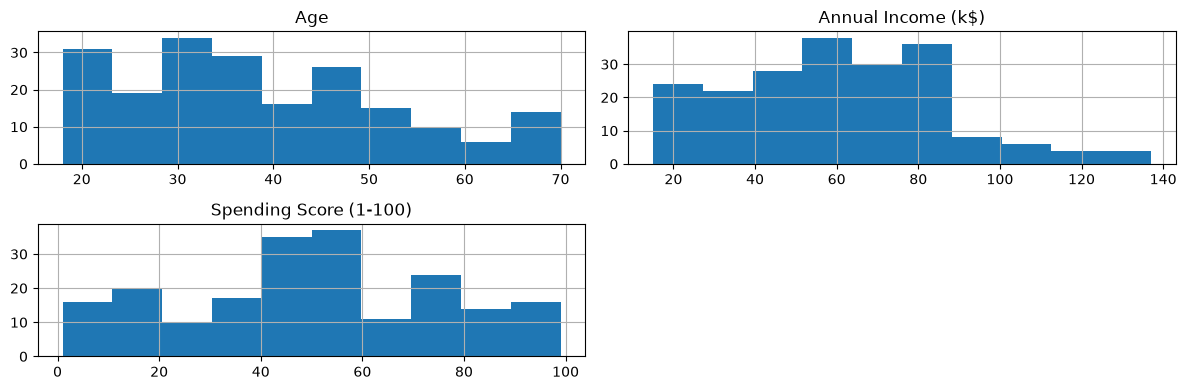

In [4]:
numeric_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

#histogram
df[numeric_columns].hist(
    figsize=(12,4)
)

plt.tight_layout()
plt.show()

Boxplot

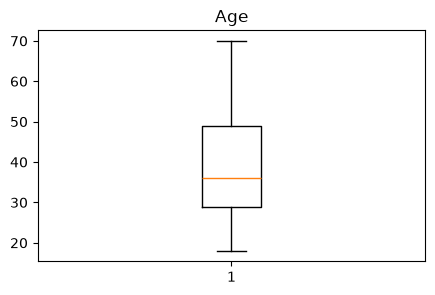

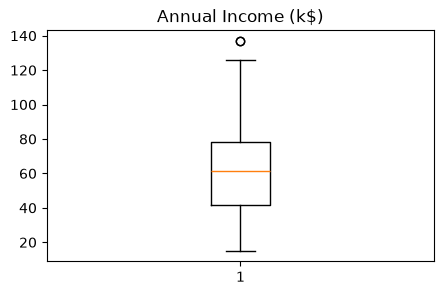

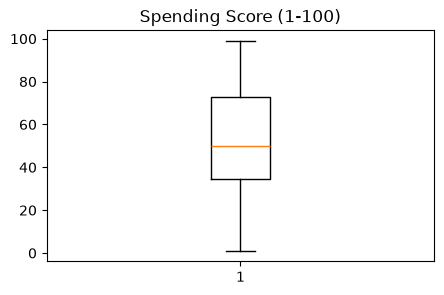

In [5]:
for column in numeric_columns:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[column])
    plt.title(column)
    plt.show()

Corelation

In [6]:
correlation = df.select_dtypes(include="number").corr()

correlation

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


Correlation Heatmap

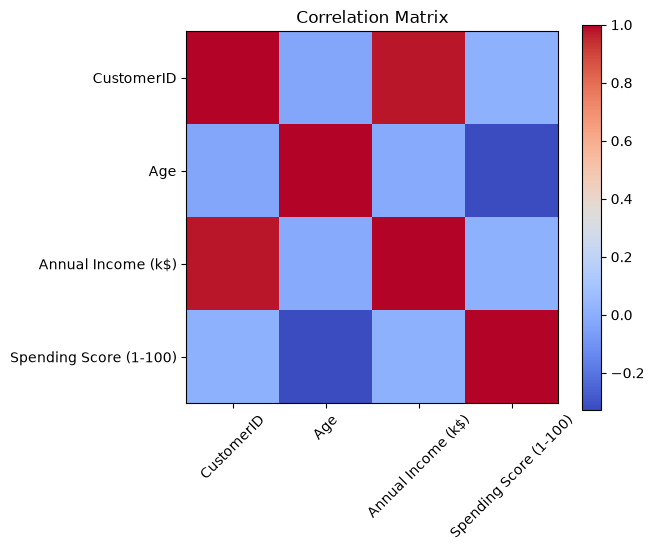

In [7]:
plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap="coolwarm")

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

Scatterplot

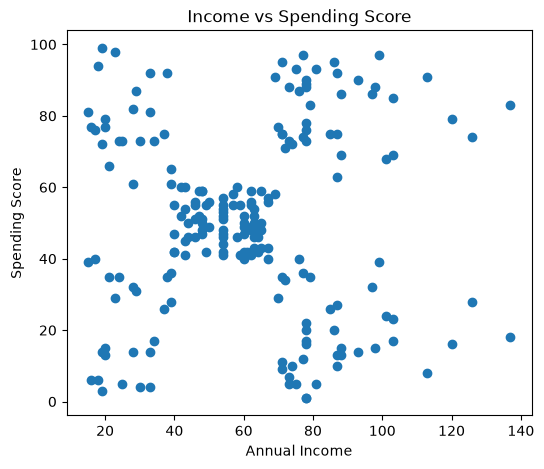

In [8]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Income vs Spending Score")

plt.show()

Observations

## Observations

- Dataset contains 200 customer records.
- No missing values.
- No duplicate records.
- CustomerID is only an identifier and not useful for clustering.
- Gender is categorical.
- Income and Spending Score appear to form natural groups.
- Age has a few potential outliers.